## 그래프 생성
## 1.1) Subjects.csv 파일을 읽어와서 'df' 변수에 저장하기
## 1.2) df DataFrame에 '총점'과 '평균' 열을 추가하여 각 학생 별 총점, 평균 점수를 입력
## 1.3) Class1반과 Class2반의 평균 점수를 각각 출력
## 1.4) Class1반과 Class2반 두 집단의 차이가 유의한지 p value 값 계산하기
## 1.5) class별 과목 분석
### 과목별 패턴 분석 : 국어를 잘하면 영어도 잘한다. 수학을 잘하면 과학도 잘한다.. 이런 패턴여부가 성립하는지 분석 > 시각화

In [2]:
%matplotlib inline
import pandas as pd
import numpy as np

## 1.1)

In [5]:
df = pd.read_csv('./data/Subjects.csv', sep=',')
df

,class,name,kor,eng,math,science
0,1,aaa,67,87,90,98
1,1,bbb,45,45,56,98
2,1,ccc,95,59,96,88
3,1,ddd,65,94,89,98
4,1,eee,45,65,78,98
5,1,fff,78,76,98,89
6,2,ggg,87,67,65,56
7,2,hhh,89,98,78,78
8,2,iii,100,78,56,65
9,2,jjj,99,89,87,87


## 1.2)

In [17]:
df['total']=df[['kor','eng','math','science']].sum(axis=1)
df['avg']=df[['kor','eng','math','science']].mean(axis=1)
df

,class,name,kor,eng,math,science,total,avg
0,1,aaa,67,87,90,98,342,85.50
1,1,bbb,45,45,56,98,244,61.00
2,1,ccc,95,59,96,88,338,84.50
3,1,ddd,65,94,89,98,346,86.50
4,1,eee,45,65,78,98,286,71.50
5,1,fff,78,76,98,89,341,85.25
6,2,ggg,87,67,65,56,275,68.75
7,2,hhh,89,98,78,78,343,85.75
8,2,iii,100,78,56,65,299,74.75
9,2,jjj,99,89,87,87,362,90.50


## 1.3)

In [18]:
 df['class'].unique()

array([1, 2])

In [25]:
class_mean = df.groupby('class')['avg'].mean()
class_mean

class
1    79.041667
2    77.125000
Name: avg, dtype: float64

In [36]:
mean_result = pd.DataFrame(class_mean, columns=['avg'])
mean_result.index = ['Class1','Class2']
mean_result

,avg
Class1,79.041667
Class2,77.125000


## 1.4)

In [47]:
from scipy.stats import ttest_ind

In [46]:
# flatten : 여러 차원(표)을 1차원 배열로 만들어주는 것
class1 = df[df['class'] == 1][['kor','eng','math','science']].values.flatten()
class2 = df[df['class'] == 2][['kor','eng','math','science']].values.flatten()

In [50]:
# np.float64(0.7064931696288617) 결과값이 0.7 정도 이므로 70% 확률로 우연이라고 함
t_stat, p_value = ttest_ind(class1,class2)
p_value

np.float64(0.7064931696288617)

## 1.5)

In [37]:
df[['kor', 'eng', 'math', 'science']].corr()

,kor,eng,math,science
kor,1.000000,0.105666,-0.060346,-0.664130
eng,0.105666,1.000000,0.532828,0.210930
math,-0.060346,0.532828,1.000000,0.563289
science,-0.664130,0.210930,0.563289,1.000000


In [38]:
import matplotlib.pyplot as plt
import seaborn as sns

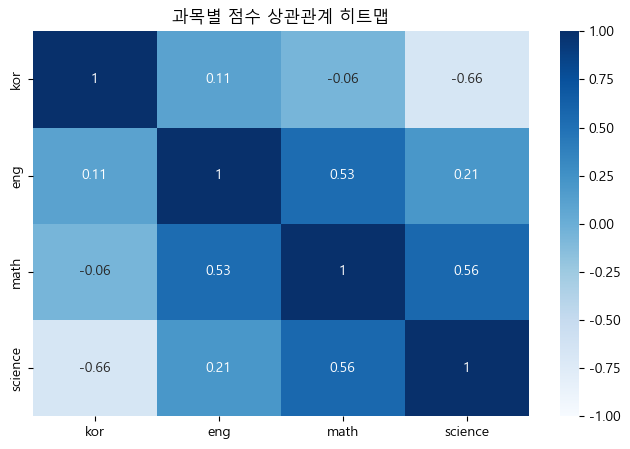

In [42]:
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

plt.figure(figsize=(8,5))
corr = df[['kor', 'eng', 'math', 'science']].corr()

sns.heatmap(corr, annot=True, cmap='Blues', vmin=-1, vmax=1)

plt.title('과목별 점수 상관관계 히트맵')
plt.show()